In [2]:
# Imports the necessary libraries for this project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr
import warnings
warnings.filterwarnings("ignore")

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.feature_selection import SelectKBest, f_classif
import joblib

In [10]:
# uploading and showing the dataset stracture
df = pd.read_csv("diabetes datasetba.csv")
print("Shape:", df.shape)
print(df.head())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (10000, 9)
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  30.0             0              0            ever  32.50   
1    Male  22.0             0              0         current  32.01   
2    Male  56.0             0              0           never  24.62   
3  Female  57.0             0              0            ever  27.32   
4    Male  60.0             0              0         current  29.51   

   HbA1c_level  blood_glucose_level  diabetes  
0          4.5                  130         0  
1          6.1                  140         0  
2          7.5                  240         1  
3          6.2                  155         0  
4          3.5                  100         0  

Data Types:
 gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabe

In [8]:
#Preprocessing
#Drop rows where gender is 'Other' (very few, not useful)
df = df[df["gender"] != "Other"].copy()

#Encode categorical columns
le_gender = LabelEncoder()
le_smoking = LabelEncoder()

df["gender"]          = le_gender.fit_transform(df["gender"])          # Female=0, Male=1
df["smoking_history"] = le_smoking.fit_transform(df["smoking_history"])

#Handle missing values — fill numeric with median
for col in df.select_dtypes(include=[np.number]).columns:
    df[col].fillna(df[col].median(), inplace=True)

#Remove outliers using IQR on numeric features
numeric_cols = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]

def remove_outliers_iqr(dataframe, columns):
    df_clean = dataframe.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    return df_clean

df_clean = remove_outliers_iqr(df, numeric_cols)
print(f"\nRows before outlier removal: {len(df)}")
print(f"Rows after  outlier removal: {len(df_clean)}")


Rows before outlier removal: 9998
Rows after  outlier removal: 7707


In [23]:
# Count before and after
before_counts = df["diabetes"].value_counts()
after_counts  = df_clean["diabetes"].value_counts()

print("="*50)
print("  CLASS DISTRIBUTION BEFORE OUTLIER REMOVAL")
print("="*50)
print(f"  No Diabetes (0) : {before_counts[0]}")
print(f"  Diabetes    (1) : {before_counts[1]}")
print(f"  Total           : {len(df)}")

print("\n" + "="*50)
print("  CLASS DISTRIBUTION AFTER OUTLIER REMOVAL")
print("="*50)
print(f"  No Diabetes (0) : {after_counts[0]}")
print(f"  Diabetes    (1) : {after_counts[1]}")
print(f"  Total           : {len(df_clean)}")
print(f"\n  Rows removed    : {len(df) - len(df_clean)}")

  CLASS DISTRIBUTION BEFORE OUTLIER REMOVAL
  No Diabetes (0) : 6500
  Diabetes    (1) : 3500
  Total           : 10000

  CLASS DISTRIBUTION AFTER OUTLIER REMOVAL
  No Diabetes (0) : 6144
  Diabetes    (1) : 1563
  Total           : 7707

  Rows removed    : 2293


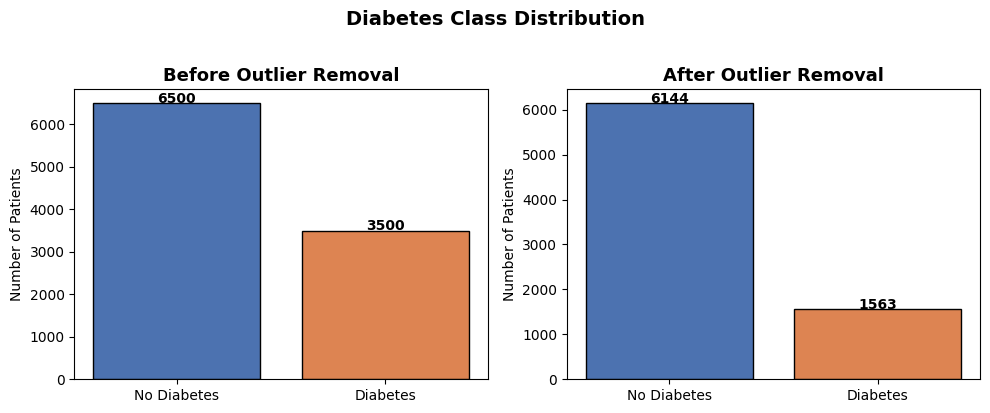


  No Diabetes : 79.7%
  Diabetes    : 20.3%


In [24]:

# Visual comparison — side by side bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

labels = ["No Diabetes", "Diabetes"]
colors = ["#4C72B0", "#DD8452"]

# Before
axes[0].bar(labels, [before_counts[0], before_counts[1]], color=colors, edgecolor="black")
axes[0].set_title("Before Outlier Removal", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Patients")
for i, v in enumerate([before_counts[0], before_counts[1]]):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

# After
axes[1].bar(labels, [after_counts[0], after_counts[1]], color=colors, edgecolor="black")
axes[1].set_title("After Outlier Removal", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Number of Patients")
for i, v in enumerate([after_counts[0], after_counts[1]]):
    axes[1].text(i, v + 10, str(v), ha="center", fontweight="bold")

plt.suptitle("Diabetes Class Distribution", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

# Percentage breakdown after removal
total_after = len(df_clean)
print(f"\n  No Diabetes : {after_counts[0]/total_after*100:.1f}%")
print(f"  Diabetes    : {after_counts[1]/total_after*100:.1f}%")

In [ ]:
#Feature Selection ────────────────────────────────
X = df_clean.drop("diabetes", axis=1)
y = df_clean["diabetes"]


In [9]:
# Select top 6 features using ANOVA F-test
selector = SelectKBest(score_func=f_classif, k=6)
selector.fit(X, y)

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Score":   selector.scores_
}).sort_values("Score", ascending=False)

print("\nFeature Importance Scores:")
print(feature_scores.to_string(index=False))


Feature Importance Scores:
            Feature       Score
        HbA1c_level 1971.250819
                age 1211.507355
                bmi  550.306004
blood_glucose_level  469.938222
       hypertension  461.537721
      heart_disease  380.494423
    smoking_history  137.403685
             gender   29.226930


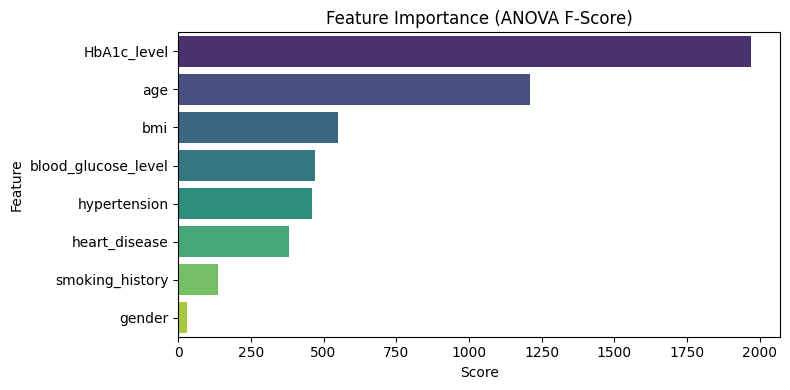

In [11]:
# Plot feature importance
plt.figure(figsize=(8, 4))
sns.barplot(data=feature_scores, x="Score", y="Feature", palette="viridis")
plt.title("Feature Importance (ANOVA F-Score)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

In [12]:
# Keep top 6 features
top_features = feature_scores["Feature"].head(6).tolist()
print("\nSelected Features:", top_features)

X_selected = X[top_features]


Selected Features: ['HbA1c_level', 'age', 'bmi', 'blood_glucose_level', 'hypertension', 'heart_disease']


In [13]:
#Train / Test Split & Normalization
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\nTraining samples: {X_train_scaled.shape[0]}")
print(f"Testing  samples: {X_test_scaled.shape[0]}")


Training samples: 6165
Testing  samples: 1542


In [14]:
#Train SVM Model
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,   # needed for confidence score
    random_state=42
)
svm_model.fit(X_train_scaled, y_train)
print("\nSVM model trained successfully.")


SVM model trained successfully.


In [15]:
#Evaluation
y_pred = svm_model.predict(X_test_scaled)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("\n" + "="*45)
print("         MODEL EVALUATION RESULTS")
print("="*45)
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print("="*45)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))


         MODEL EVALUATION RESULTS
  Accuracy  : 0.8748  (87.48%)
  Precision : 0.7521
  Recall    : 0.5719
  F1 Score  : 0.6497

Classification Report:

              precision    recall  f1-score   support

 No Diabetes       0.90      0.95      0.92      1229
    Diabetes       0.75      0.57      0.65       313

    accuracy                           0.87      1542
   macro avg       0.82      0.76      0.79      1542
weighted avg       0.87      0.87      0.87      1542



In [19]:
#Cross-validation
cv_scores = cross_val_score(svm_model,
                            X_selected, y, cv=5, scoring="accuracy")
print(f"5-Fold Cross-Validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

5-Fold Cross-Validation Accuracy: 0.8094 ± 0.0039


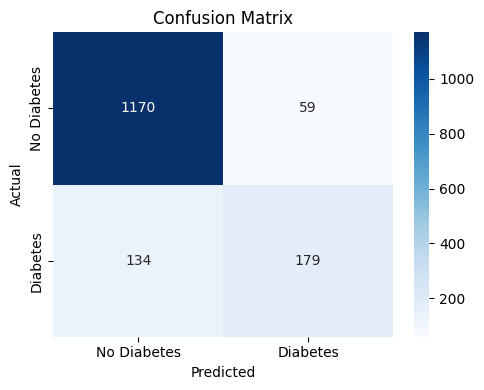

In [20]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [25]:
#Save Model & Scaler
joblib.dump(svm_model, "svm_diabetes_model.pkl")
joblib.dump(scaler,    "scaler.pkl")
print("\nModel and scaler saved.")


Model and scaler saved.


In [27]:
# downloading to computer
from google.colab import files
files.download("svm_diabetes_model.pkl")
files.download("scaler.pkl")

# Also print your top_features list so you can copy it exactly
print("top_features =", top_features)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

top_features = ['HbA1c_level', 'age', 'bmi', 'blood_glucose_level', 'hypertension', 'heart_disease']
